<a href="https://colab.research.google.com/github/elajeans/IMAG2023/blob/main/oppgave3_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

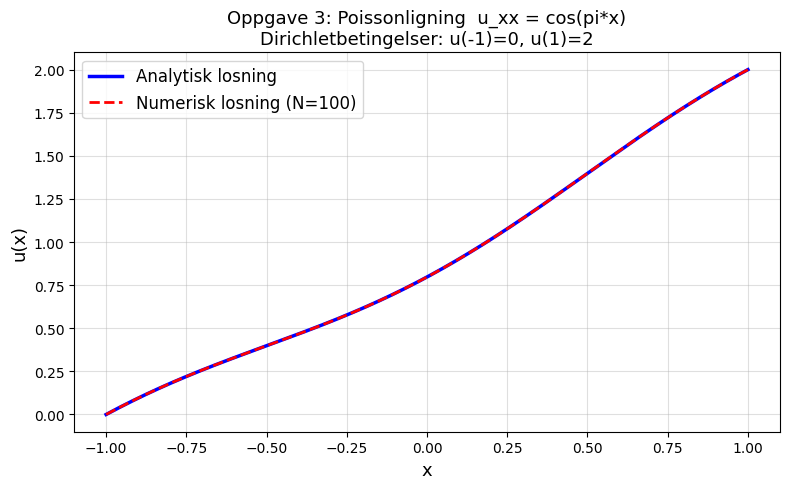

C1 = 1,  C2 = 1 - 1/pi^2 = 0.89868
Maks feil: 6.53e-05


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# OPPGAVE 3: Poissonligning 1D
# Differensiallikning: u_xx = cos(pi*x),  -1 <= x <= 1
#
# Randbetingelser (Dirichletbetingelser):
#   u(-1) = 0   og   u(1) = 2
#
# Dirichletbetingelser = vi setter VERDIEN av losningen pa randen.
# (Ikke den deriverte -- selve funksjonen.)

# DEL A: ANALYTISK LOSNING
# Vi integrerer cos(pi*x) to ganger:
#
#   1. integrasjon:  u'(x) = sin(pi*x)/pi + C1
#   2. integrasjon:  u(x)  = -cos(pi*x)/pi^2 + C1*x + C2
#
# Bruk randbetingelsene (Dirichlet) for a finne C1 og C2:
#
#   u(-1) = 0:   1/pi^2 - C1 + C2 = 0     ...(i)
#   u( 1) = 2:   1/pi^2 + C1 + C2 = 2     ...(ii)
#
#   (ii) + (i) => 2*C2 = 2 - 2/pi^2  =>  C2 = 1 - 1/pi^2
#   (ii) - (i) => 2*C1 = 2            =>  C1 = 1
#
#   Analytisk losning:  u(x) = -cos(pi*x)/pi^2 + x + 1 - 1/pi^2

def u_analytisk(x):
    return -np.cos(np.pi * x) / np.pi**2 + x + 1 - 1/np.pi**2



# DEL B: NUMERISK LOSNING (finite differanser)

# Diskretiser [-1,1] i N+2 punkter med steglengde h = 2/(N+1).
#
# Sentral differanse for andrederiverte:
#   u_xx ~ (u_{i-1} - 2*u_i + u_{i+1}) / h^2
#
# Gir tridiagonalt lineaert system  A*u = b  der:
#   A = tridiag(1, -2, 1) / h^2
#   b_i = cos(pi*x_i)
#
# Dirichletbetingelsene paforeres ved a justere hoyreside:
#   b[0]  -= u(-1)/h^2 = 0/h^2
#   b[-1] -= u( 1)/h^2 = 2/h^2

N = 100
x_num = np.linspace(-1, 1, N + 2)
h = x_num[1] - x_num[0]

A = (np.diag(-2*np.ones(N)) +
     np.diag( np.ones(N-1),  1) +
     np.diag( np.ones(N-1), -1)) / h**2

b = np.cos(np.pi * x_num[1:-1])
b[0]  -= 0 / h**2   # Dirichlet: u(-1) = 0
b[-1] -= 2 / h**2   # Dirichlet: u( 1) = 2

u_num = np.linalg.solve(A, b)
u_full = np.concatenate([[0], u_num, [2]])


# PLOT
x_fine = np.linspace(-1, 1, 500)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(x_fine, u_analytisk(x_fine), 'b-',  lw=2.5, label='Analytisk losning')
ax.plot(x_num,  u_full,              'r--', lw=2,   label=f'Numerisk losning (N={N})')
ax.set_xlabel('x', fontsize=13)
ax.set_ylabel('u(x)', fontsize=13)
ax.set_title('Oppgave 3: Poissonligning  u_xx = cos(pi*x)\n'
             'Dirichletbetingelser: u(-1)=0, u(1)=2', fontsize=13)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

print(f"C1 = 1,  C2 = 1 - 1/pi^2 = {1 - 1/np.pi**2:.5f}")
print(f"Maks feil: {np.max(np.abs(u_full - u_analytisk(x_num))):.2e}")